# Step 2 — Floodscan Benchmark

Calculates the historical flooding time series for the target area using Floodscan SFED (Surface Fraction Exposed to Flooding). This benchmark is the ground truth used in all subsequent steps to evaluate forecast skill and calibrate trigger thresholds.

Sanity checks assess whether Floodscan captures what is known about historical flooding in this location (known flood years from reports, seasonal pattern).

**Inputs** (from blob storage):
- Floodscan pixel-level parquet: `cfg["floodscan_blob"]` — pre-processed by `10_floodscan_processing.ipynb`

**Outputs** saved to blob storage:
```
ds-aa-nga-flooding/processed/workflow/{state}_floodscan_daily.parquet
ds-aa-nga-flooding/processed/workflow/{state}_floodscan_annual.parquet
```
Daily columns: `date`, `mean_sfed`  
Annual columns: `year`, `max_sfed`, `mean_sfed_rp`

**Next step**: `03_forecast_correlation.ipynb` — measure correlation between forecast signals and this benchmark.

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.utils.rp_calc import calculate_one_group_rp

load_dotenv()

True

In [25]:
# ── Config ────────────────────────────────────────────────────────────────────
STATE = "Benue"  # "Adamawa" or "Benue"

cfg = STATE_CONFIG[STATE]
ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR   = cfg["analysis_end_year"]
RP_LEVELS = [3, 4, 5]

BLOB_DAILY  = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_floodscan_daily.parquet"
BLOB_ANNUAL = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_floodscan_annual.parquet"

FIGURES_DIR = Path(f"figures/{STATE.lower()}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Load Floodscan Data

In [26]:
df_pixels = stratus.load_parquet_from_blob(cfg["floodscan_blob"])
df_pixels["date"] = pd.to_datetime(df_pixels["date"])

print(f"Pixels: {df_pixels[['x', 'y']].drop_duplicates().shape[0]}")
print(f"Date range: {df_pixels['date'].min().date()} – {df_pixels['date'].max().date()}")
print(f"Rows: {len(df_pixels):,}")

Pixels: 40
Date range: 1998-01-12 – 2025-12-31
Rows: 408,640


## Daily Mean SFED Time Series

Aggregate to a single daily value by taking the mean SFED across all selected pixels.

In [27]:
df_daily = (
    df_pixels.groupby("date")["SFED"]
    .mean()
    .reset_index()
    .rename(columns={"SFED": "mean_sfed"})
)
df_daily = df_daily[
    df_daily["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()

print(f"Daily records: {len(df_daily):,}  ({ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR})")

Daily records: 9,485  (1998–2023)


## Annual Maxima and Return Periods

In [28]:
df_annual_max = (
    df_daily.assign(year=df_daily["date"].dt.year)
    .groupby("year")["mean_sfed"]
    .max()
    .reset_index()
    .rename(columns={"mean_sfed": "max_sfed"})
)

df_annual_rp = calculate_one_group_rp(
    df_annual_max.rename(columns={"max_sfed": "mean"}),
    col_name="mean",
    ascending=False,
).rename(columns={"mean": "max_sfed", "mean_rp": "max_sfed_rp"})

for rp in RP_LEVELS:
    df_annual_rp[f"flood_{rp}yr"] = (df_annual_rp["max_sfed_rp"] >= rp).astype(int)

df_annual_rp.sort_values("year", ascending=False).head(10)

,year,max_sfed,mean_rank,max_sfed_rp,flood_3yr,flood_4yr,flood_5yr
25,2023,0.066552,15,1.800000,0,0,0
24,2022,0.244456,2,13.500000,1,1,1
23,2021,0.040092,22,1.227273,0,0,0
22,2020,0.079201,10,2.700000,0,0,0
21,2019,0.140569,4,6.750000,1,1,1
20,2018,0.097792,9,3.000000,1,0,0
19,2017,0.099425,8,3.375000,1,0,0
18,2016,0.109988,6,4.500000,1,1,0
17,2015,0.147396,3,9.000000,1,1,1
16,2014,0.119731,5,5.400000,1,1,1


## Sanity Checks

### 1 — Seasonal Pattern

Floodscan should show a strong peak in Aug–Oct (the Niger–Benue flood season).

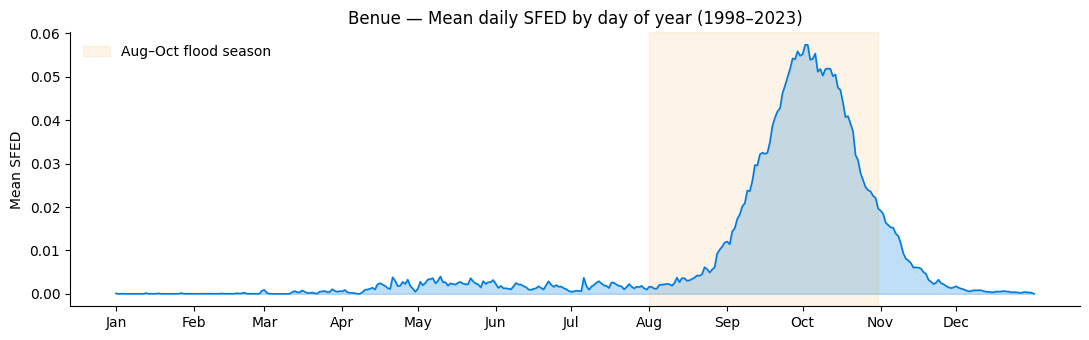

In [29]:
df_doy = (
    df_daily.assign(doy=df_daily["date"].dt.dayofyear)
    .groupby("doy")["mean_sfed"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(df_doy["doy"], df_doy["mean_sfed"], color="#007CE0", alpha=0.25)
ax.plot(df_doy["doy"], df_doy["mean_sfed"], color="#007CE0", linewidth=1.2)

# Mark Aug–Oct flood season
aug1 = pd.Timestamp("2001-08-01").dayofyear
oct31 = pd.Timestamp("2001-10-31").dayofyear
ax.axvspan(aug1, oct31, color="#F4A93B", alpha=0.12, label="Aug–Oct flood season")

month_starts = [pd.Timestamp(f"2001-{m:02d}-01").dayofyear for m in range(1, 13)]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_ylabel("Mean SFED")
ax.set_title(f"{STATE} — Mean daily SFED by day of year ({ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR})")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_fs_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()

### 2 — Annual Maximum SFED

Bar chart of peak SFED per year. Years classified as flood events (≥ 3-yr RP) are highlighted.

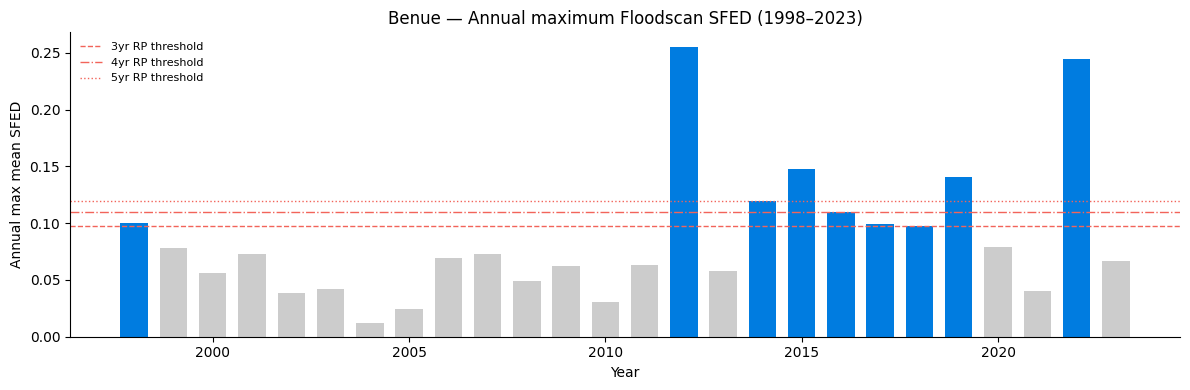

In [30]:
df_plot = df_annual_rp.sort_values("year")
colors = ["#007CE0" if v else "#CCCCCC" for v in df_plot["flood_3yr"]]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_plot["year"], df_plot["max_sfed"], color=colors, width=0.7)

# RP threshold lines
for rp, ls, label in zip(
    RP_LEVELS,
    ["--", "-.", ":"],
    ["3yr RP", "4yr RP", "5yr RP"],
):
    thresh = df_annual_rp.loc[df_annual_rp["max_sfed_rp"] >= rp, "max_sfed"].min()
    ax.axhline(thresh, color="#F2645A", linestyle=ls, linewidth=1, label=f"{label} threshold")

ax.set_xlabel("Year")
ax.set_ylabel("Annual max mean SFED")
ax.set_title(f"{STATE} — Annual maximum Floodscan SFED ({ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR})")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_fs_annual_max.png", dpi=150, bbox_inches="tight")
plt.show()

### 3 — Flood Event Years

Heatmap of flood event years at each RP level. Cross-check against known major flood years in the literature for this state.

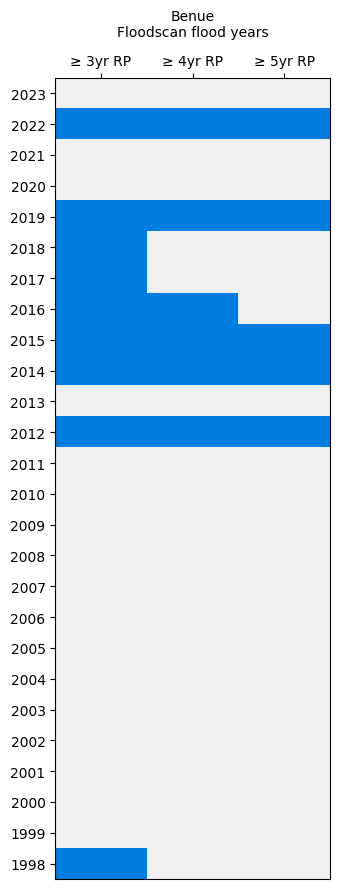

≥ 3yr RP flood years (9): [1998, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2022]
≥ 4yr RP flood years (6): [2012, 2014, 2015, 2016, 2019, 2022]
≥ 5yr RP flood years (5): [2012, 2014, 2015, 2019, 2022]


In [31]:
heatmap_matrix = df_annual_rp.set_index("year")[
    [f"flood_{rp}yr" for rp in RP_LEVELS]
].sort_index(ascending=False)
heatmap_matrix.columns = [f"≥ {rp}yr RP" for rp in RP_LEVELS]

cmap = mcolors.ListedColormap(["#F0F0F0", "#007CE0"])

fig, ax = plt.subplots(figsize=(3.5, 9))
ax.imshow(heatmap_matrix.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(RP_LEVELS)))
ax.set_xticklabels(heatmap_matrix.columns)
ax.set_yticks(range(len(heatmap_matrix)))
ax.set_yticklabels(heatmap_matrix.index)
ax.xaxis.tick_top()
ax.set_title(f"{STATE}\nFloodscan flood years", fontsize=10, pad=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_fs_flood_years.png", dpi=150, bbox_inches="tight")
plt.show()

for rp in RP_LEVELS:
    years = sorted(df_annual_rp.loc[df_annual_rp[f"flood_{rp}yr"] == 1, "year"].tolist())
    print(f"≥ {rp}yr RP flood years ({len(years)}): {years}")

### 4 — Peak Timing

Distribution of the day-of-year when annual peak SFED occurs. Should cluster in Sep–Oct.

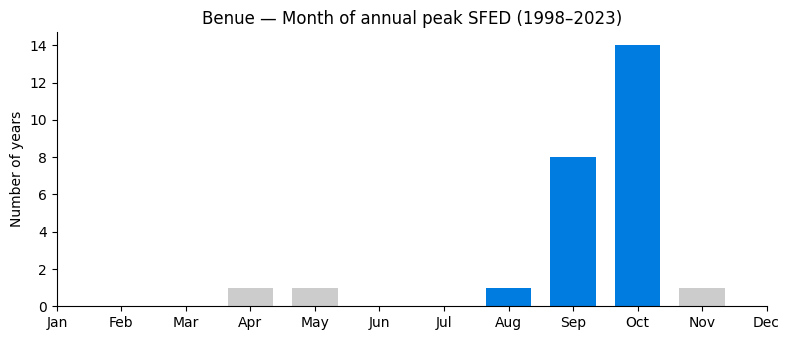

Median peak date: 02 Oct


In [32]:
df_peak_timing = (
    df_daily.assign(year=df_daily["date"].dt.year)
    .loc[df_daily["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)]
    .sort_values("mean_sfed", ascending=False)
    .drop_duplicates(subset="year")
    .assign(peak_doy=lambda x: x["date"].dt.dayofyear,
            peak_month=lambda x: x["date"].dt.month)
)

month_counts = df_peak_timing["peak_month"].value_counts().sort_index()
month_labels_all = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(
    month_counts.index,
    month_counts.values,
    color=["#007CE0" if m in [8, 9, 10] else "#CCCCCC" for m in month_counts.index],
    width=0.7,
)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels_all)
ax.set_ylabel("Number of years")
ax.set_title(f"{STATE} — Month of annual peak SFED ({ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_fs_peak_timing.png", dpi=150, bbox_inches="tight")
plt.show()

median_doy = int(df_peak_timing["peak_doy"].median())
median_date = pd.Timestamp("2001-01-01") + pd.Timedelta(days=median_doy - 1)
print(f"Median peak date: {median_date.strftime('%d %b')}")

## Save

In [33]:
stratus.upload_parquet_to_blob(df_daily, BLOB_DAILY)
print(f"Saved daily SFED ({len(df_daily):,} rows) to {BLOB_DAILY}")

stratus.upload_parquet_to_blob(df_annual_rp, BLOB_ANNUAL)
print(f"Saved annual RP ({len(df_annual_rp)} years) to {BLOB_ANNUAL}")

Saved daily SFED (9,485 rows) to ds-aa-nga-flooding/processed/workflow/benue_floodscan_daily.parquet
Saved annual RP (26 years) to ds-aa-nga-flooding/processed/workflow/benue_floodscan_annual.parquet
